# 02 — RFM Feature Engineering

Computes Recency, Frequency, and Monetary value per customer — the three features that go
into clustering in notebook 03.

- **Recency:** days since the customer's most recent purchase (lower = more recently active)
- **Frequency:** number of distinct purchase occasions (invoices)
- **Monetary:** total amount spent

Output: `data/customer_rfm.csv`

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
%matplotlib inline

df = pd.read_csv("../data/retail_clean.csv", parse_dates=["invoice_date"])
df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,line_total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 1. Set a Snapshot Date

RFM needs a fixed reference point for "today" — using the day after the last transaction in
the dataset keeps this reproducible regardless of when you actually run the notebook.

In [2]:
snapshot_date = df["invoice_date"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

Snapshot date: 2011-12-10


## 2. Compute RFM per Customer

In [3]:
rfm = df.groupby("customer_id").agg(
    recency=("invoice_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("invoice_no", "nunique"),
    monetary=("line_total", "sum"),
).reset_index()

rfm["monetary"] = rfm["monetary"].round(2)
print(f"RFM computed for {len(rfm):,} customers")
rfm.head()

RFM computed for 4,338 customers


,customer_id,recency,frequency,monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


## 3. Inspect RFM Distributions

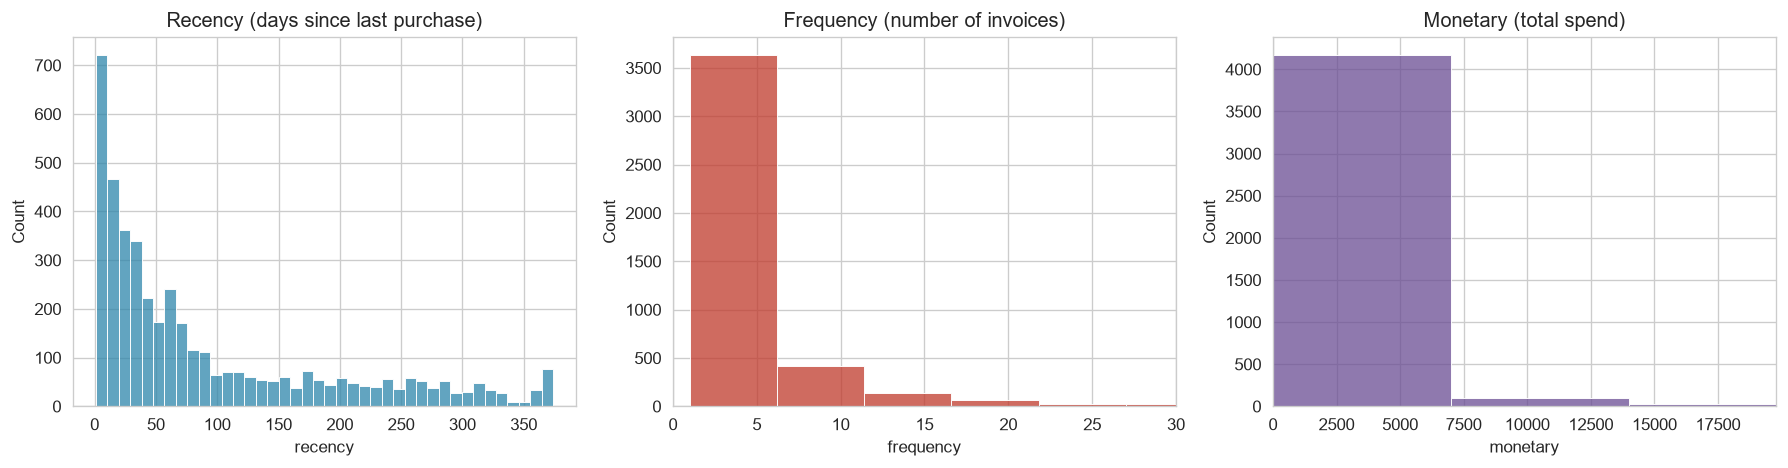

,recency,frequency,monetary
count,4338.000000,4338.000000,4338.00000
mean,92.536422,4.272015,2048.68808
std,100.014169,7.697998,8985.23022
min,1.000000,1.000000,3.75000
25%,18.000000,1.000000,306.48250
50%,51.000000,2.000000,668.57000
75%,142.000000,5.000000,1660.59750
max,374.000000,209.000000,280206.02000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["recency"], bins=40, ax=axes[0], color="#2E86AB")
axes[0].set_title("Recency (days since last purchase)")

sns.histplot(rfm["frequency"], bins=40, ax=axes[1], color="#C0392B")
axes[1].set_title("Frequency (number of invoices)")
axes[1].set_xlim(0, rfm["frequency"].quantile(0.99))

sns.histplot(rfm["monetary"], bins=40, ax=axes[2], color="#6A4C93")
axes[2].set_title("Monetary (total spend)")
axes[2].set_xlim(0, rfm["monetary"].quantile(0.99))

plt.tight_layout()
plt.savefig("../visuals/rfm_distributions.png", dpi=150)
plt.show()

rfm[["recency", "frequency", "monetary"]].describe()

**Note:** All three distributions are typically right-skewed in retail data — most customers buy infrequently and spend modestly, while a small number of high-value customers pull the distribution's tail out. This is expected and part of why clustering is useful here: a simple average would be misleading given this skew.

## 4. Handle Outliers

A small number of extreme outliers (e.g. wholesale buyers placing unusually large orders) can
distort K-Means, since it's distance-based. Cap extreme values at the 99th percentile rather
than dropping these customers entirely — they're real customers, just extreme ones.

In [5]:
for col in ["frequency", "monetary"]:
    cap = rfm[col].quantile(0.99)
    n_capped = (rfm[col] > cap).sum()
    rfm[col] = rfm[col].clip(upper=cap)
    print(f"{col}: capped {n_capped} outlier(s) at the 99th percentile ({cap:.2f})")

frequency: capped 42 outlier(s) at the 99th percentile (30.00)
monetary: capped 44 outlier(s) at the 99th percentile (19780.49)


## 5. Scale Features

K-Means uses distance between points, so features on very different scales (recency in days
vs. monetary in currency, often 100x-1000x larger) must be standardized first, or monetary
value will dominate the clustering regardless of recency/frequency.

In [6]:
from sklearn.preprocessing import StandardScaler

features = rfm[["recency", "frequency", "monetary"]]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=["recency_scaled", "frequency_scaled", "monetary_scaled"])
rfm_scaled_df["customer_id"] = rfm["customer_id"].values

rfm_scaled_df.head()

,recency_scaled,frequency_scaled,monetary_scaled,customer_id
0,2.334574,-0.618713,6.523365,12346
1,-0.905340,0.615110,0.974681,12347
2,-0.175360,-0.001801,0.073448,12348
3,-0.735345,-0.618713,0.059212,12349
4,2.174578,-0.618713,-0.451218,12350


## 6. Save RFM Data (Raw and Scaled)

In [7]:
rfm.to_csv("../data/customer_rfm.csv", index=False)
rfm_scaled_df.to_csv("../data/customer_rfm_scaled.csv", index=False)
print("Saved customer_rfm.csv (raw values, for interpretation) and "
      "customer_rfm_scaled.csv (for clustering in notebook 03)")

Saved customer_rfm.csv (raw values, for interpretation) and customer_rfm_scaled.csv (for clustering in notebook 03)
